Plot a map showing Euler's jounrney from Basel to St Petersburg in 1727

Load the required libraries

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib_scalebar.scalebar import ScaleBar

Define Euler's waypoints

In [26]:
# Expanded route based on Euler's 1727 itinerary
euler_route = {
    "Basel": (7.58, 47.55),
    "Mainz": (8.27, 50.00),      # End of the Rhine boat leg
    "Frankfurt": (8.68, 50.11),
    "Kassel": (9.47, 51.31),     # Famous meeting with Wolff
    "Hannover": (9.73, 52.37),
    "Hamburg": (9.99, 53.55),
    "Lübeck": (10.68, 53.86),    # Port of departure for the Baltic
    "W1": (13.44, 54.99), # Waypoint 1
    "W2": (15.46, 54.83), # Waypoint 2
    "W3": (20.21, 57.39), # Waypoint 3
    "W4": (21.08, 59.04), # Waypoint 4
    "W5": (23.94, 59.63), # Waypoint 5
    "Reval": (24.75, 59.43),   # Tallinn
    "W6": (24.60, 59.71), # Waypoint 6
    "W7": (27.94, 59.89), # Waypoint 7
    "W8": (29.36, 60.05), # Waypoint 8
    "St. Petersburg": (30.33, 59.93)
}

lons = [coords[0] for coords in euler_route.values()]
lats = [coords[1] for coords in euler_route.values()]
city_names = list(euler_route.keys())

In [27]:
context_cities = {
    "London": (-0.12, 51.50),
    "Paris": (2.35, 48.85),
    "Berlin": (13.40, 52.52),
    "Copenhagen": (12.56, 55.67),
    "Stockholm": (18.06, 59.32),
    "Christiana": (10.75, 59.91), # Modern-day Oslo
    "Prague": (14.43, 50.07),
    "Warsaw": (21.01, 52.23),
    "Riga": (24.10, 56.94)
}

c_lons = [coords[0] for coords in context_cities.values()]
c_lats = [coords[1] for coords in context_cities.values()]

Plot a map, with the route.

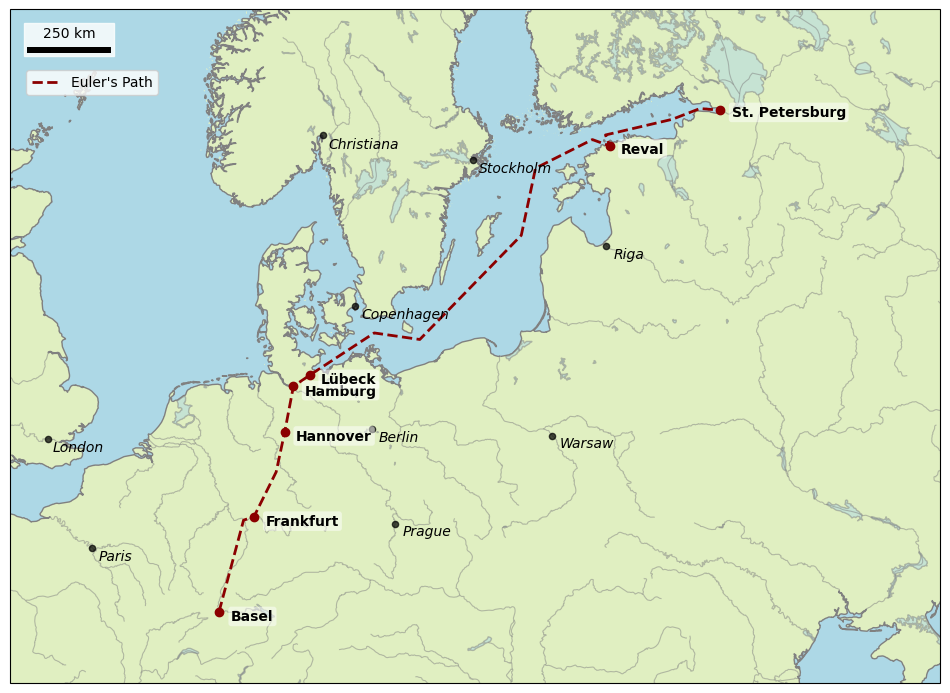

In [40]:
fig = plt.figure(figsize=(12, 10))

# 1. Create the map with a European focus
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=15, central_latitude=53))
ax.set_extent([0, 35, 45, 62], crs=ccrs.PlateCarree())

mapres = '10m'
#mapres = '110m'

# 2. Add geographic features for a "vintage" feel
rivers = cfeature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', mapres,
                edgecolor='gray', facecolor='none', linewidth=0.8, alpha=0.5)
lakes = cfeature.NaturalEarthFeature('physical', 'lakes', mapres,
                edgecolor='gray', facecolor='lightblue', alpha=0.5)
coastline = cfeature.NaturalEarthFeature('physical', 'coastline', mapres,
                edgecolor='gray', facecolor='none', linewidth=1)
ocean = cfeature.NaturalEarthFeature('physical', 'ocean', mapres,
                                     facecolor='lightblue')
land = cfeature.NaturalEarthFeature('physical', 'land', mapres,
                                    facecolor='yellowgreen', alpha=0.3)

ax.add_feature(ocean)
ax.add_feature(land)
ax.add_feature(lakes)
ax.add_feature(rivers)
ax.add_feature(coastline)
#ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)

# Plot Context Cities
ax.scatter(c_lons, c_lats, color='k', s=20, alpha=0.7, 
           transform=ccrs.PlateCarree(), zorder=5)

# Add Labels for Context Cities
# Using a slightly smaller, italic font to distinguish from Euler's route
for name, (lon, lat) in context_cities.items():
    ax.text(lon + 0.3, lat - 0.3, name, transform=ccrs.PlateCarree(), 
            fontsize=10, color='k', style='italic', zorder=10)
    
# 3. Plot the route line
ax.plot(lons, lats, color='darkred', linewidth=2, linestyle = '--',
        transform=ccrs.PlateCarree(), label="Euler's Path")

# Place shaded box behind city names
text_bbox = dict(
    facecolor='white', 
    alpha=0.5,          # Transparency (0 is clear, 1 is opaque)
    edgecolor='none',   # Removes the border for a cleaner look
    boxstyle='round,pad=0.2'  # Rounded corners with a little breathing room
)
# 4. Label the cities
for name in ["Basel", "Hamburg", "Reval", "Frankfurt", "Hannover", "Lübeck", "St. Petersburg"]:
    lon, lat = euler_route[name]
    ax.text(lon + 0.5, lat-0.2, name, fontsize=10, fontweight='bold',
            bbox=text_bbox,  # Add the box here
            zorder=11,        # Ensure it sits above the map features
            transform=ccrs.PlateCarree())
    ax.scatter(lon, lat, color='darkred', marker='o',
               transform=ccrs.PlateCarree(), zorder=6)

# Create the scale bar with fixed length and specific ticks
scalebar = ScaleBar(
    1, 
    units="m", 
    location="upper left", 
    fixed_value=250,        # Total length
    fixed_units="km",       # Units
    box_alpha=0.8, 
    border_pad=1,
    scale_loc="top"
)

ax.add_artist(scalebar)

ax.legend(loc='upper left', bbox_to_anchor=(0.01, 0.92), 
          fontsize=10, frameon=True, facecolor='white', framealpha=0.8)

#plt.title("Leonhard Euler's Journey: Basel to St. Petersburg (1727)", fontsize=14)
plt.savefig("Euler_1727.png")
